# GlowCare Customer Purchase Prediction

This project aims to build a Machine Learning Classification Model to predict whether a customer will purchase the GlowCare serum product based on customer behavior and demographic data.

## Importing Required Libraries

In this section, we import all the necessary libraries for data analysis, preprocessing, visualization, model training, and evaluation.

In [258]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

## Loading the Dataset

The dataset contains customer information collected from the GlowCare skincare application and store.

In [259]:
df = pd.read_excel("/content/GlowCare_Customer_Data.xlsx")


## Exploring the Dataset

Before training the model, we explore the dataset structure, columns, and statistical information.

In [260]:
df.head()


,Age,Income_Level,Skincare_Interest_Score,Daily_App_Time_Mins,Previous_Purchases,Will_Buy_Serum
0,46,Medium,97,11,9,1
1,32,Low,53,11,4,0
2,25,Low,86,37,4,1
3,38,Medium,31,9,5,0
4,36,Medium,52,21,9,1


In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Income_Level             1000 non-null   object
 2   Skincare_Interest_Score  1000 non-null   int64 
 3   Daily_App_Time_Mins      1000 non-null   int64 
 4   Previous_Purchases       1000 non-null   int64 
 5   Will_Buy_Serum           1000 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 47.0+ KB


In [262]:
df.describe()

,Age,Skincare_Interest_Score,Daily_App_Time_Mins,Previous_Purchases,Will_Buy_Serum
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,36.507000,53.776000,23.043000,5.604000,0.50000
std,10.960478,25.335503,12.355801,3.389494,0.50025
min,18.000000,10.000000,2.000000,0.000000,0.00000
25%,27.000000,32.000000,12.000000,3.000000,0.00000
50%,37.000000,54.000000,23.000000,6.000000,0.50000
75%,46.000000,75.000000,34.000000,9.000000,1.00000
max,54.000000,99.000000,44.000000,11.000000,1.00000


## Checking Missing Values

In this step, we check if the dataset contains any missing or null values.

In [263]:
df.isnull().sum()

,0
Age,0
Income_Level,0
Skincare_Interest_Score,0
Daily_App_Time_Mins,0
Previous_Purchases,0
Will_Buy_Serum,0


No missing values were found in the dataset.
However, a preprocessing pipeline was prepared for robustness

## Encoding Categorical Features

The Income_Level feature was already represented numerically in the dataset.
However, Label Encoding was prepared in the preprocessing pipeline for handling categorical values if needed in future datasets.

In [264]:
encoder = LabelEncoder()

df["Income_Level"] = encoder.fit_transform(df["Income_Level"])

## Defining Features and Target Variable

The target variable is Will_Buy_Serum, while the remaining columns are used as input features.

In [265]:
X = df.drop("Will_Buy_Serum", axis=1)

y = df["Will_Buy_Serum"]

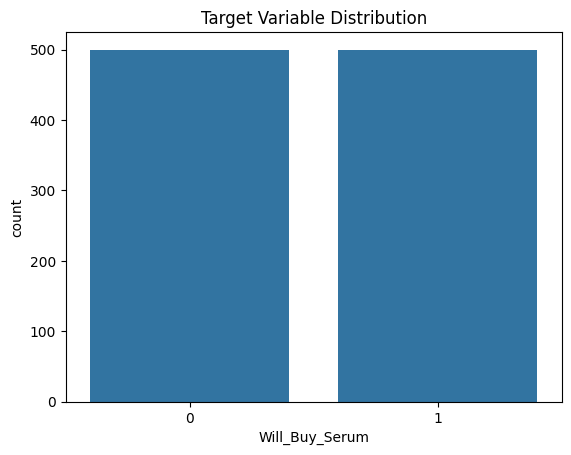

In [266]:
sns.countplot(x="Will_Buy_Serum", data=df)

plt.title("Target Variable Distribution")

plt.show()

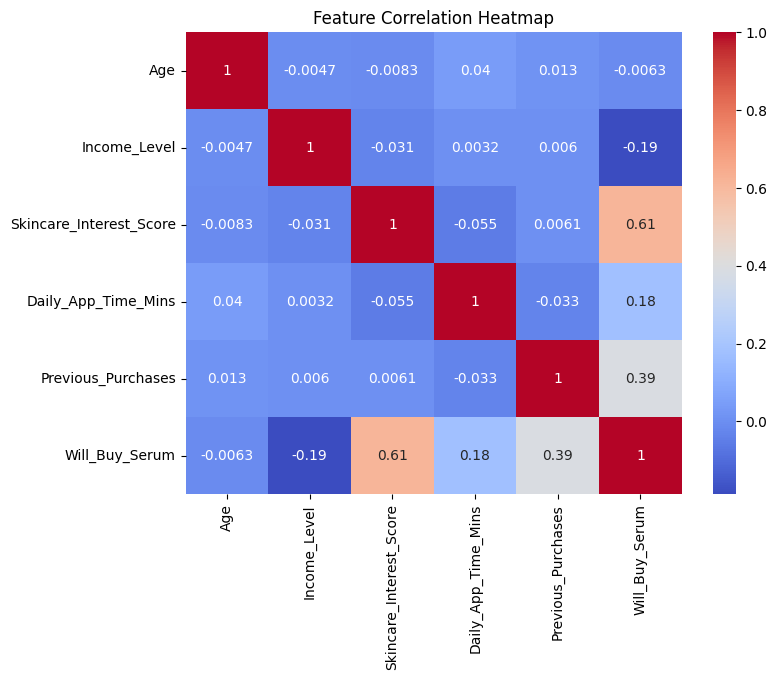

In [267]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

## Splitting the Dataset

The dataset is divided into training and testing sets using an 80:20 ratio.

In [268]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Feature scaling was applied to normalize numerical values and improve Logistic Regression performance.

In [269]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression is used as a baseline classification model.

In [270]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [271]:
log_predictions = log_model.predict(X_test_scaled)

In [272]:
log_cm = confusion_matrix(y_test, log_predictions)

## Logistic Regression Evaluation

The model performance is evaluated using Accuracy, Precision, Recall, and F1-score.

In [273]:
log_acc = accuracy_score(y_test, log_predictions)

print(f"Logistic Regression Accuracy: {log_acc*100:.2f}%")

print(classification_report(y_test, log_predictions))

Logistic Regression Accuracy: 88.00%
              precision    recall  f1-score   support

           0       0.86      0.91      0.88        99
           1       0.91      0.85      0.88       101

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



#Logistic Confusion Matrix


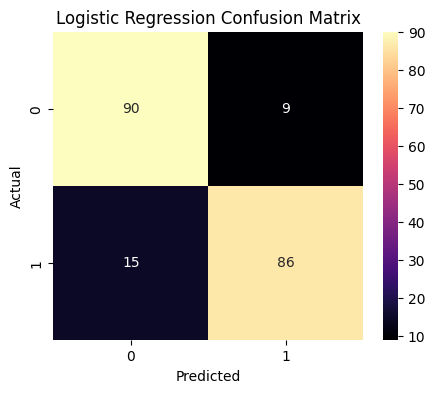

In [274]:
plt.figure(figsize=(5,4))

sns.heatmap(
    log_cm,
    annot=True,
    fmt='d',
    cmap='magma'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()


## Random Forest Classifier

Random Forest is used to improve prediction performance and handle feature interactions effectively.

In [275]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [276]:
rf_predictions = rf_model.predict(X_test)

In [277]:
rf_cm = confusion_matrix(y_test, rf_predictions)

## Random Forest Evaluation

The Random Forest model is evaluated using classification metrics.

In [278]:
rf_acc = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 94.50%
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        99
           1       0.92      0.98      0.95       101

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



Random Forest Confusion Matrix

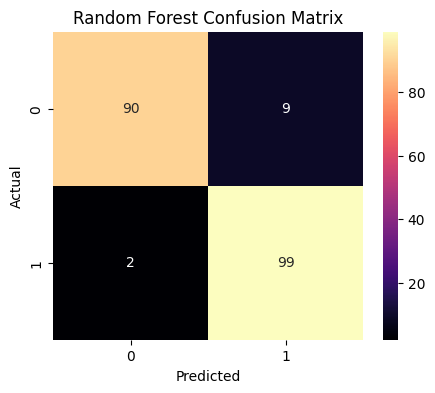

In [279]:
plt.figure(figsize=(5,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='magma'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

## Comparing Model Performance

The following comparison shows the accuracy of both classification models.

In [280]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_acc, rf_acc]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.880
1,Random Forest,0.945


## Final Model Selection

Random Forest achieved the highest prediction accuracy (94.5%) compared to Logistic Regression (88%).

Therefore, Random Forest was selected as the final model for customer purchase prediction.

## Feature Importance Analysis

This visualization shows which features have the strongest influence on customer purchase predictions.

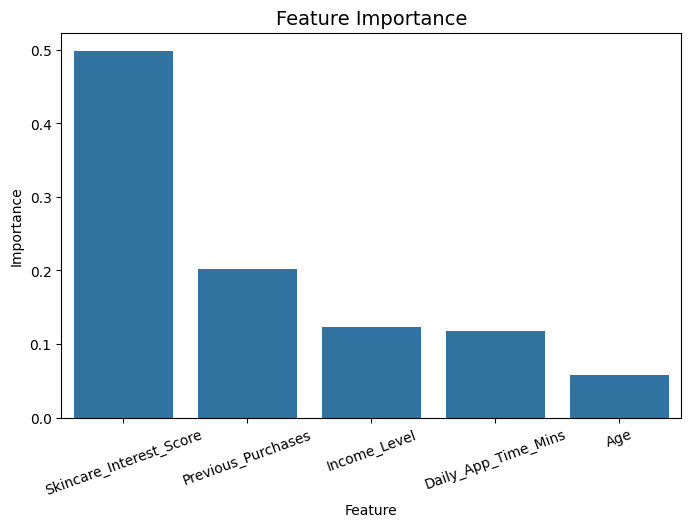

In [281]:
importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Feature",
    y="Importance",
    data=importance_df
)

plt.title("Feature Importance", fontsize=14)

plt.xticks(rotation=20)

plt.show()

## Customer Purchase Prediction Example

The trained model can predict whether a new customer is likely to purchase the serum product.

In [282]:
# Age, Income_Level, Skincare_Interest_Score,
# Daily_App_Time_Mins, Previous_Purchases

ample_customer = [[30, 2, 85, 40, 5]]

prediction = rf_model.predict(sample_customer)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [283]:
if prediction[0] == 2:
    print("The customer is likely to buy the serum.")
else:
    print("The customer is unlikely to buy the serum.")

The customer is unlikely to buy the serum.


## Saving the Trained Model

The trained Random Forest model is saved for future deployment and usage.

In [284]:
joblib.dump(rf_model, "GlowCare_RF_Model.pkl")

['GlowCare_RF_Model.pkl']

# Conclusion

The Random Forest model achieved strong performance in predicting customer purchasing behavior for GlowCare serum products.

This model can help the business:
- Identify potential buyers
- Improve marketing strategies
- Increase product sales
- Enhance customer targeting